# Hito2


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.metrics import make_scorer, mean_absolute_error
import seaborn as sns
import matplotlib.pyplot as plt



# Configuración de visualización para gráficos más atractivos
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

## Aplicando sugerencias del profesor:

Debido al desbalance de clases, se implementa un parametro "Class_weight = balanced", de esta manera dandole mayor peso a clases de menor frecuencia. 
De esta manera se evita que el modelo tenga sesgo hacia la clase mayoritaria, y a su vez mejora el desempeño en predicciones hacia clases minoritarias.

**Funciona de esta forma:**

 El algoritmo penaliza los erroes al identificar una clase proporcionalmente a su valor de WEIGHT CLASS. De esta manera cuando el algoritmo se equivoca en una clase con alto peso, habra una mayor penalizacion, haciendo que el modelo ponga mas enfasis en clasificar correctamente aquellos tipos de datos.

### Trabajando la primera pregunta: 

¿Es posible predecir la popularidad de una canción a partir de sus características musicales?

***Regresion lineal:***

In [8]:
# Carga de datos
file_name = 'dataset.csv'
df = pd.read_csv(file_name)
df['explicit'] = df['explicit'].astype(int)

train_df, test_df = train_test_split(df, test_size=0.2, random_state=666)

features_to_use = [
    'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode',
    'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence',
    'tempo', 'time_signature', 'track_genre'
]
# sets entrenamiento y prueba
y_train = train_df['popularity']
y_test = test_df['popularity']

X_train = train_df[features_to_use]
X_test = test_df[features_to_use]
# convertimos columnas de género en columnas numéricas
X_train= pd.get_dummies(X_train, columns=['track_genre'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['track_genre'], drop_first=True)


# forzamos a que ambos conjuntos tengan las mismas columnas de género

train_cols = X_train.columns
test_cols = X_test.columns
missing_in_test = set(train_cols) - set(test_cols)
for c in missing_in_test:
    X_test[c] = 0
missing_in_train = set(test_cols) - set(train_cols)
for c in missing_in_train:
    X_train[c] = 0
X_test = X_test[train_cols] # asegura el mismo orden


linear_model = LinearRegression(n_jobs=-1)
kf = KFold(n_splits=5, shuffle=True, random_state=666)


print("===== CROSS VALIDATION  MAE RESULTS =====")

mae_scores = cross_val_score(linear_model, X_train, y_train, 
            scoring='neg_mean_absolute_error', cv=kf)

print("MAE por fold:", -mae_scores)
print("MAE promedio CV:", -mae_scores.mean())
print("Desviación estándar CV:", mae_scores.std())
print("====================================\n")



print("===== CROSS VALIDATION  R2 RESULTS =====")

r2_scores = cross_val_score(linear_model,X_train, y_train, scoring= 'r2',cv=kf)

print("R2 por fold:", r2_scores)
print("R2 promedio CV:", r2_scores.mean())
print("Desviación estándar CV:", r2_scores.std())
print("====================================\n")


print("===== RESULTS MODELO FINAL =====")

linear_model.fit(X_train, y_train)
predictions = linear_model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"MAE en test: {mae}")
print(f"R² en test: {r2}")

===== CROSS VALIDATION  MAE RESULTS =====
MAE por fold: [14.31885466 14.01965354 13.97454227 14.14521287 14.09633785]
MAE promedio CV: 14.110920238088408
Desviación estándar CV: 0.11962768392545767

===== CROSS VALIDATION  R2 RESULTS =====
R2 por fold: [0.25157766 0.2621944  0.26111357 0.24851218 0.25907885]
R2 promedio CV: 0.25649533247049694
Desviación estándar CV: 0.005447867923316055

===== RESULTS MODELO FINAL =====
MAE en test: 14.07172419404308
R² en test: 0.2615407333800547


## Pasando al RandomForestRegressor:

In [10]:
# RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor


rf_regressor = RandomForestRegressor(n_estimators=50, max_depth=20, random_state=666, n_jobs=-1)


kf = KFold(n_splits=3, shuffle=True, random_state=666)

print("===== CROSS VALIDATION  MAE RESULTS =====")

rf_mae_scores = cross_val_score( rf_regressor, X_train, y_train,
            scoring='neg_mean_absolute_error', cv=kf)

print("RF - MAE por fold:", -rf_mae_scores)
print("RF - MAE promedio:", -rf_mae_scores.mean())
print("RF - Desv std:", rf_mae_scores.std())


print("===== CROSS VALIDATION  R2 RESULTS =====")
rf_r2_scores = cross_val_score( rf_regressor,X_train,y_train,
            scoring='r2', cv=kf)

print("RF - R2 por fold:", rf_r2_scores)
print("RF - R2 promedio:", rf_r2_scores.mean())
print("RF - Desv std:", rf_r2_scores.std())



print("===== RESULTS MODELO FINAL =====")
rf_regressor.fit(X_train, y_train)
rf_predictions = rf_regressor.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_r2 = r2_score(y_test, rf_predictions)

print(f"RandomForestRegressor - MAE: {rf_mae}")
print(f"RandomForestRegressor - R²: {rf_r2}")

#

===== CROSS VALIDATION  MAE RESULTS =====
RF - MAE por fold: [15.90684348 15.75558076 16.00605148]
RF - MAE promedio: 15.889491905600202
RF - Desv std: 0.10298771084540152
===== CROSS VALIDATION  R2 RESULTS =====
RF - R2 por fold: [0.19036492 0.19016536 0.17893269]
RF - R2 promedio: 0.186487656944353
RF - Desv std: 0.005342791608567582
===== RESULTS MODELO FINAL =====
RandomForestRegressor - MAE: 15.871812120886073
RandomForestRegressor - R²: 0.19013799724049385


**Aclaracion** Baje varias cosas tanto del forest, como de los folds para que se pueda hacer en menor tiempo (con los datos de originales se tardaba +20 minutos)

## Random Forest Classifier:

Precisión (Accuracy): 0.7703070175438597

Reporte de Clasificación:
              precision    recall  f1-score   support

 Muy Popular       0.71      0.42      0.53      2714
Poco Popular       0.78      0.92      0.85     13465
     Popular       0.75      0.61      0.67      6621

    accuracy                           0.77     22800
   macro avg       0.75      0.65      0.68     22800
weighted avg       0.76      0.77      0.76     22800


Matriz de Confusión:


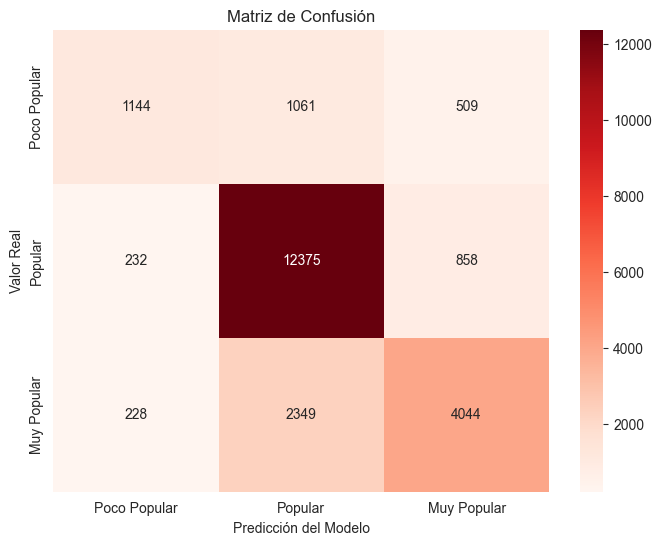

In [4]:
file_name = 'dataset.csv'
df = pd.read_csv(file_name)
# pasamos explicit a numerico
df['explicit'] = df['explicit'].astype(int)

#le damos una etiqueta a cada cancion segun su popularidad
bins = [-1, 40, 60, 101]
labels = ['Poco Popular', 'Popular', 'Muy Popular']
df['popularity_category'] = pd.cut(df['popularity'], bins=bins, labels=labels)


# usamos stratify para mantener la proporción en train y test
train_df, test_df = train_test_split(df, test_size=0.2, random_state=666, stratify=df['popularity_category'])

features_to_use = [
    'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode',
    'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence',
    'tempo', 'time_signature', 'track_genre'
]

# sets entrenamiento y prueba
y_train = train_df['popularity_category']
y_test = test_df['popularity_category']

X_train = train_df[features_to_use]
X_test = test_df[features_to_use]

# convertimos columnas de género en columnas numéricas
X_train = pd.get_dummies(X_train, columns=['track_genre'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['track_genre'], drop_first=True)

# forzamos a que ambos conjuntos tengan las mismas columnas de género
train_cols = X_train.columns
test_cols = X_test.columns
missing_in_test = set(train_cols) - set(test_cols)
for c in missing_in_test:
    X_test[c] = 0
X_test = X_test[train_cols] # asegura el mismo orden


clf_model = RandomForestClassifier(n_estimators=100, random_state=666, n_jobs=-1, class_weight='balanced')

clf_model.fit(X_train, y_train)

predictions = clf_model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
report = classification_report(y_test, predictions)
conf_matrix = confusion_matrix(y_test, predictions)

print(f"Precisión (Accuracy): {accuracy}")
print("\nReporte de Clasificación:")
print(report)


print("\nMatriz de Confusión:")
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt = 'd',cmap='Reds', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión')
plt.show()

#con n_jobs=-1 se demora 12 seg. Con n_jobs=1 se demora 45 seg.

Aqui falta hacer la cross_val_Score pero me dio lata...

Con eso estaria lista la 1ra pregunta. (No se si quiza deberiamos hacer en el df un atributo que de mayor peso segun el artista pero weno.)

### 1. ¿Es posible predecir el género de una canción a partir de sus características de audio como energía, tempo o bailabilidad?
 

Precisión (Accuracy): 0.12460526315789473

Reporte de Clasificación:
                   precision    recall  f1-score   support

         acoustic       0.08      0.07      0.07       200
         afrobeat       0.08      0.06      0.06       200
         alt-rock       0.01      0.01      0.01       200
      alternative       0.09      0.10      0.09       200
          ambient       0.11      0.12      0.12       200
            anime       0.04      0.03      0.04       200
      black-metal       0.20      0.20      0.20       200
        bluegrass       0.05      0.04      0.05       200
            blues       0.09      0.07      0.08       200
           brazil       0.02      0.01      0.02       200
        breakbeat       0.11      0.10      0.10       200
          british       0.06      0.06      0.06       200
         cantopop       0.07      0.07      0.07       200
    chicago-house       0.22      0.28      0.25       200
         children       0.19      0.20      0

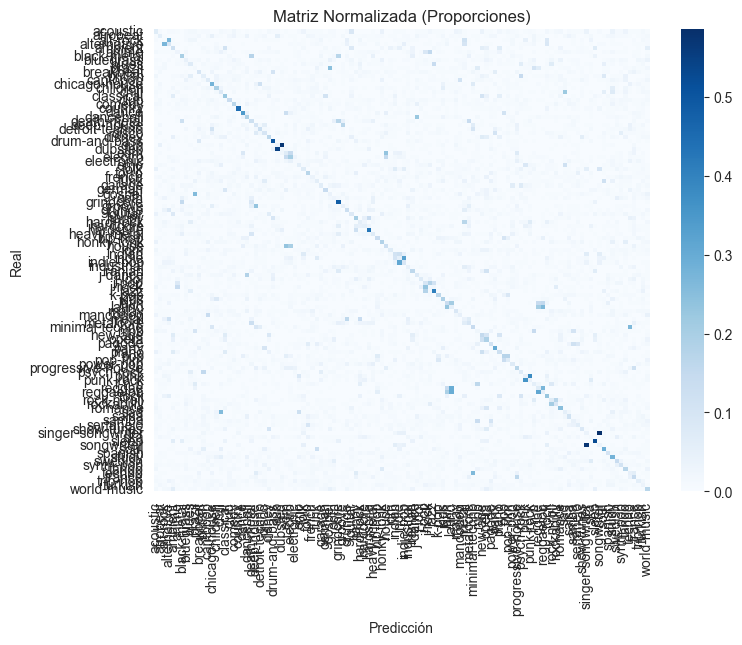

In [5]:
file_name = 'dataset.csv'
df = pd.read_csv(file_name)
class_names = sorted(df['track_genre'].unique())


# usamos stratify para mantener la proporción en train y test
train_df, test_df = train_test_split(df, test_size=0.2, random_state=666, stratify=df['track_genre'])

features_to_use = [
    'danceability', 'energy', 'tempo',
]

# sets entrenamiento y prueba
y_train = train_df['track_genre']
y_test = test_df['track_genre']

X_train = train_df[features_to_use]
X_test = test_df[features_to_use]


rtc_model = RandomForestClassifier(n_estimators=100, random_state=666, n_jobs=-1, class_weight='balanced')

rtc_model.fit(X_train, y_train)

predictions = rtc_model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
report = classification_report(y_test, predictions)
conf_matrix = confusion_matrix(y_test, predictions)

print(f"Precisión (Accuracy): {accuracy}")
print("\nReporte de Clasificación:")
print(report)





conf_norm = conf_matrix / conf_matrix.sum(axis=1, keepdims=True)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_norm, annot=False, cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Matriz Normalizada (Proporciones)")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()


#print("\nMatriz de Confusión:")
#plt.figure(figsize=(14, 12))
#sns.heatmap(conf_matrix, annot=True, fmt = 'd',cmap='Reds', xticklabels=class_names , yticklabels= class_names)
#plt.xlabel('Predicción del Modelo')
#plt.ylabel('Valor Real')
#plt.title('Matriz de Confusión')
#plt.show()

#con n_jobs=-1 se demora 12 seg. Con n_jobs=1 se demora 45 seg.